<a href="https://colab.research.google.com/github/UmmeQulsumAfifa21/bd-price-forecast/blob/main/Teacher_Demo_Preprocessing_v2_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bangladesh Commodity Price Predictor — Data Preprocessing Pipeline

This notebook prepares all the data used by the project, in two parts:

| Part | Input (collected data) | Output |
|---|---|---|
| **A. Yearly DAM data** (original project pipeline) | `chicken.csv`, `rice.csv`, `fish.csv` — DAM market prices, one per market per year (2025, 2026) | `district_prices_clean.csv` (real yearly district averages) and `monthly_hybrid.csv` (monthly series reconstructed from them) |
| **B. Real monthly data** (new) | `wfp_food_prices_bgd_Raw_.csv` (WFP, district-level monthly retail prices) and `All_division.zip` (DAM/MOA Monthly Average Price Reports) | `real_monthly_upload.csv` — real monthly prices ready for the app's **Admin → Upload data**, followed by **Admin → Retrain model** |

**How to run:** upload the files in Step 0, then **Runtime → Run all**. Everything is saved and downloaded as one zip at the end.

## Step 0 — Upload the input files

Run the next cell and select these files together (hold `Ctrl`):

**Required:** `chicken.csv`, `rice.csv`, `fish.csv`, `wfp_food_prices_bgd_Raw_.csv`, `All_division.zip`

**Optional** (only for the exact-match check in Step 7): the project's current `district_prices_clean.csv` and `monthly_hybrid.csv`.

If the upload button does not appear, open the 📁 panel on the left and drag the files into `/content`.

In [ ]:
from pathlib import Path
import os, shutil

BASE = Path("/content") if Path("/content").exists() else Path.cwd()
RAW = BASE / "data" / "raw"
PROCESSED = BASE / "data" / "processed"
OUTPUTS = BASE / "outputs"
for folder in (RAW, PROCESSED, OUTPUTS):
    folder.mkdir(parents=True, exist_ok=True)

RAW_NAMES = {"chicken.csv", "rice.csv", "fish.csv"}
try:
    from google.colab import files
    uploaded = files.upload()
    for filename, content in uploaded.items():
        target = RAW / filename if filename in RAW_NAMES else BASE / filename
        target.write_bytes(content)
        print("Saved:", target)
except ImportError:
    print("Not running in Google Colab - using files already in:", BASE)

# Files dragged into /content instead of uploaded: move the three raw DAM files into data/raw
for name in RAW_NAMES:
    if (BASE / name).exists() and not (RAW / name).exists():
        shutil.move(str(BASE / name), str(RAW / name))

required = [RAW / n for n in sorted(RAW_NAMES)] + [BASE / "wfp_food_prices_bgd_Raw_.csv", BASE / "All_division.zip"]
missing = [p.name for p in required if not p.exists()]
print("\nMissing files:", missing if missing else "none - ready to run")


Missing files: none - ready to run


# Part A — Yearly DAM data → district prices and monthly series

This part reproduces the project's original preprocessing (`notebooks/01_data_preparation.ipynb`).

## Step 1 — Import libraries and define the raw schema

The raw DAM files contain 12 columns.  
The project renames them to a fixed schema so the later preprocessing is consistent.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

COLUMNS = [
    "Division", "location", "Upazila", "Market_Name", "commodity", "Year",
    "Retail_Unit", "Retail_Price_Range", "price_per_kg",
    "Wholesale_Unit", "Wholesale_Price_Range", "Wholesale_Avg_Price"
]

print("Raw folder:", RAW)
print("Processed folder:", PROCESSED)


Raw folder: /content/data/raw
Processed folder: /content/data/processed


## Step 2 — Clean each raw commodity file

Cleaning rules used by the current project:

- read using `utf-8-sig`
- remove commas from numeric price text, e.g. `1,712.50 → 1712.50`
- convert the average retail price to numeric
- remove rows where price is missing
- remove prices `<= 0`
- convert `Year` to integer
- calculate the median price separately for each commodity
- flag a row as suspicious if its price is:
  - more than **3 × commodity median**, or
  - less than **commodity median / 3**

The suspicious rows are printed instead of being silently discarded.


In [ ]:
def load_and_clean(path, category):
    d = pd.read_csv(path, encoding="utf-8-sig")

    assert len(d.columns) == len(COLUMNS), (
        f"{path}: expected {len(COLUMNS)} columns, found {len(d.columns)}"
    )

    d.columns = COLUMNS
    d["category"] = category

    # "1,712.50" -> 1712.50
    d["price_per_kg"] = pd.to_numeric(
        d["price_per_kg"].astype(str).str.replace(",", "", regex=False),
        errors="coerce"
    )

    # Remove missing and impossible non-positive prices
    d = d.dropna(subset=["price_per_kg"])
    d = d[d["price_per_kg"] > 0].copy()
    d["Year"] = d["Year"].astype(int)

    # Current project's 3× median plausibility/outlier rule
    median = d.groupby("commodity")["price_per_kg"].transform("median")
    outliers = (
        (d["price_per_kg"] > median * 3) |
        (d["price_per_kg"] < median / 3)
    )

    removed = d.loc[
        outliers,
        [
            "location", "Market_Name", "commodity", "Year",
            "Retail_Price_Range", "price_per_kg"
        ]
    ].copy()

    kept = d.loc[
        ~outliers,
        ["Year", "location", "commodity", "category", "price_per_kg"]
    ].copy()

    return kept, removed


## Step 3 — Run cleaning for Chicken, Rice and Fish

This cell shows the number of rows retained and the suspicious rows removed.


In [ ]:
clean_parts = []
removed_parts = []

for name, category in [
    ("chicken", "Chicken"),
    ("rice", "Rice"),
    ("fish", "Fish")
]:
    kept, removed = load_and_clean(RAW / f"{name}.csv", category)

    print(
        f"{name:8s}: {len(kept):5d} rows kept, "
        f"{len(removed)} suspicious rows removed"
    )

    clean_parts.append(kept)
    removed_parts.append(removed)

removed_df = pd.concat(removed_parts, ignore_index=True)

print("\nSuspicious rows removed:")
display(removed_df)


chicken :   422 rows kept, 2 suspicious rows removed
rice    :   921 rows kept, 3 suspicious rows removed
fish    :  1050 rows kept, 4 suspicious rows removed

Suspicious rows removed:


,location,Market_Name,commodity,Year,Retail_Price_Range,price_per_kg
0,Lalmonirhat,Lalmonirhat Sadar Bazar,Sonali Chicken,2026,"318.88--1,763.04",1040.96
1,Jamalpur,Jamalpur Sadar Bazar,Sonali Chicken,2026,"3,409.72--320.45",1865.09
2,Madaripur,"Sadar Bazar, Madaripur",Kalojira,2026,952.92--194.79,573.85
3,Panchagarh,Panchagarh Sadar Bazar,Ricel-Boro-Mota,2025,"1,050.9--51.75",551.33
4,Gaibandha,Gaibandha Sadar Bazar,Rice - Atap,2026,200--230,215.00
5,Rangamati,Kaptai Bazar,Telapia/Nilotica,2026,"997.98--1,118.88",1058.43
6,Rajshahi,Rajshahi Sadar Bazar,Hilsha (500-900) gm,2025,"1,204.51--7,550.38",4591.73
7,Rajshahi,Rajshahi Sadar Bazar,Hilsha (500-900) gm,2026,"1,301.3--23,012.99",12157.14
8,Chapainawabganj,Shibgonj Sadar Bazar,Magur,2026,133.8--138.8,136.30


### Expected result with the current project raw files

- Chicken: **422 kept, 2 removed**
- Rice: **921 kept, 3 removed**
- Fish: **1050 kept, 4 removed**

Total suspicious rows removed: **9**


## Step 4 — Create real district-level yearly prices

There may be several markets inside one district.

The project groups by:

`Year + location + commodity + category`

and calculates the arithmetic mean of `price_per_kg`.

This produces `district_prices_clean.csv`.


In [ ]:
all_clean = pd.concat(clean_parts, ignore_index=True)

district_df = (
    all_clean
    .groupby(
        ["Year", "location", "commodity", "category"],
        as_index=False
    )["price_per_kg"]
    .mean()
)

years_per_series = (
    district_df
    .groupby(["location", "commodity"])["Year"]
    .nunique()
)

print("District-level rows:", len(district_df))
print("Districts:", district_df["location"].nunique())
print("Commodities:", district_df["commodity"].nunique())
print("Series with both 2025 and 2026:", int((years_per_series == 2).sum()))
print("Series with only one year:", int((years_per_series == 1).sum()))

district_path = PROCESSED / "district_prices_clean.csv"
district_df.to_csv(district_path, index=False)

print("\nSaved:", district_path)
display(district_df.head(10))


District-level rows: 1918
Districts: 64
Commodities: 65
Series with both 2025 and 2026: 846
Series with only one year: 226

Saved: /content/data/processed/district_prices_clean.csv


,Year,location,commodity,category,price_per_kg
0,2025,Bagerhat,Broiler chicken,Chicken,170.69
1,2025,Bagerhat,Grass carp,Fish,215.00
2,2025,Bagerhat,Hilsha (500-900) gm,Fish,1139.14
3,2025,Bagerhat,Katla-Medium (2.50-4.50 kg),Fish,325.00
4,2025,Bagerhat,Katla-Small (1.50-2.00 kg),Fish,260.00
5,2025,Bagerhat,Mregal-small,Fish,225.00
6,2025,Bagerhat,Pangash (big),Fish,192.52
7,2025,Bagerhat,Rice-Boro-Fine,Rice,75.00
8,2025,Bagerhat,Rice-Boro-Medium,Rice,59.19
9,2025,Bagerhat,Ricel-Boro-Mota,Rice,50.69


### Expected result

- **1,918** district-level rows
- **64** districts
- **65** commodities
- **846** district–commodity series with both 2025 and 2026 data


## Step 5 — Generate the monthly hybrid series

For each district–commodity series that has both 2025 and 2026:

1. Take the 2025 district average as the starting price
2. Take the 2026 district average as the ending price
3. Create 24 monthly dates from Jan-2025 to Dec-2026
4. Create a linear trend using `np.linspace`
5. Add normally distributed random noise with standard deviation = **3% of the 2025 price**
6. Use `np.random.seed(42)` so the generated values are reproducible
7. Keep months up to `CUTOFF_MONTH` (2026-09, the last month in the project's data). Using a fixed month instead of "today" means the result is identical whenever the notebook is run - otherwise running it in October would add a month and the Step 7 check would no longer match the project's file.

This reproduces the project's `monthly_hybrid.csv`.


In [ ]:
np.random.seed(42)

def generate_monthly(group):
    prices_by_year = group.set_index("Year")["price_per_kg"]

    if 2025 not in prices_by_year.index or 2026 not in prices_by_year.index:
        return None

    start_price = prices_by_year.loc[2025]
    end_price = prices_by_year.loc[2026]

    months = pd.date_range(
        "2025-01-01",
        "2026-12-01",
        freq="MS"
    )

    trend = np.linspace(
        start_price,
        end_price,
        len(months)
    )

    noise = np.random.normal(
        loc=0,
        scale=start_price * 0.03,
        size=len(months)
    )

    return pd.DataFrame({
        "date": months,
        "price_per_kg": trend + noise
    })


monthly_parts = []

for (location, commodity), group in district_df.groupby(
    ["location", "commodity"]
):
    generated = generate_monthly(group)

    if generated is not None:
        generated["location"] = location
        generated["commodity"] = commodity
        generated["category"] = group["category"].iloc[0]
        monthly_parts.append(generated)

monthly_df = pd.concat(monthly_parts, ignore_index=True)

# Keep only months up to the cut-off month
CUTOFF_MONTH = "2026-09"   # last month in the project's data; set to None to use the current month
this_month = (pd.Timestamp(CUTOFF_MONTH) if CUTOFF_MONTH else pd.Timestamp.today().to_period("M").to_timestamp())
monthly_df = (
    monthly_df[monthly_df["date"] <= this_month]
    .reset_index(drop=True)
)

monthly_path = PROCESSED / "monthly_hybrid.csv"
monthly_df.to_csv(monthly_path, index=False)

print("Monthly rows:", len(monthly_df))
print(
    "Series:",
    monthly_df.groupby(["location", "commodity"]).ngroups
)
print(
    "Coverage:",
    monthly_df["date"].min().strftime("%Y-%m"),
    "to",
    monthly_df["date"].max().strftime("%Y-%m")
)
print("\nSaved:", monthly_path)

display(monthly_df.head(10))


Monthly rows: 17766
Series: 846
Coverage: 2025-01 to 2026-09

Saved: /content/data/processed/monthly_hybrid.csv


,date,price_per_kg,location,commodity,category
0,2025-01-01,173.233524,Bagerhat,Broiler chicken,Chicken
1,2025-02-01,170.519381,Bagerhat,Broiler chicken,Chicken
2,2025-03-01,175.081401,Bagerhat,Broiler chicken,Chicken
3,2025-04-01,180.101153,Bagerhat,Broiler chicken,Chicken
4,2025-05-01,171.640536,Bagerhat,Broiler chicken,Chicken
5,2025-06-01,172.178011,Bagerhat,Broiler chicken,Chicken
6,2025-07-01,182.001023,Bagerhat,Broiler chicken,Chicken
7,2025-08-01,178.381542,Bagerhat,Broiler chicken,Chicken
8,2025-09-01,172.585093,Bagerhat,Broiler chicken,Chicken
9,2025-10-01,178.304809,Bagerhat,Broiler chicken,Chicken


### Expected result

- **17,766** monthly rows
- **846** district–commodity series
- Coverage: **Jan-2025 to Sep-2026**


## Step 6 — Visual inspection

A simple plot is useful when demonstrating the preprocessing to a supervisor.


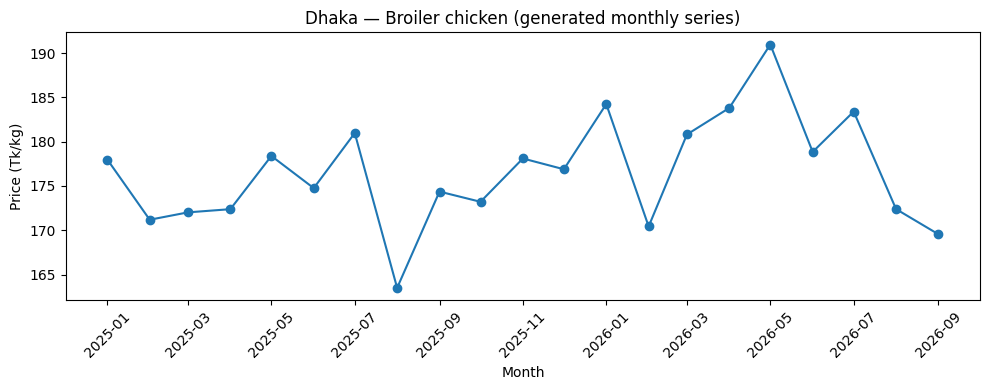

,date,price_per_kg,location,commodity,category
3675,2025-01-01,177.981554,Dhaka,Broiler chicken,Chicken
3676,2025-02-01,171.187871,Dhaka,Broiler chicken,Chicken
3677,2025-03-01,172.019428,Dhaka,Broiler chicken,Chicken
3678,2025-04-01,172.379897,Dhaka,Broiler chicken,Chicken
3679,2025-05-01,178.382871,Dhaka,Broiler chicken,Chicken
3680,2025-06-01,174.753786,Dhaka,Broiler chicken,Chicken
3681,2025-07-01,180.969319,Dhaka,Broiler chicken,Chicken
3682,2025-08-01,163.495654,Dhaka,Broiler chicken,Chicken
3683,2025-09-01,174.361998,Dhaka,Broiler chicken,Chicken
3684,2025-10-01,173.211778,Dhaka,Broiler chicken,Chicken


In [ ]:
example = monthly_df[
    (monthly_df["location"] == "Dhaka") &
    (monthly_df["commodity"] == "Broiler chicken")
].copy()

plt.figure(figsize=(10, 4))
plt.plot(
    example["date"],
    example["price_per_kg"],
    marker="o"
)
plt.title("Dhaka — Broiler chicken (generated monthly series)")
plt.xlabel("Month")
plt.ylabel("Price (Tk/kg)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

display(example)


## Step 7 — Optional exact verification against the current project files

If you also uploaded the current project's existing:

- `district_prices_clean.csv`
- `monthly_hybrid.csv`

this cell checks whether this notebook reproduced them.

Because the project uses `np.random.seed(42)`, the monthly values are reproducible.


In [ ]:
existing_district = BASE / "district_prices_clean.csv"
existing_monthly = BASE / "monthly_hybrid.csv"

if existing_district.exists():
    old_district = pd.read_csv(existing_district)

    same_district = (
        district_df.round(12)
        .reset_index(drop=True)
        .equals(
            old_district.round(12)
            .reset_index(drop=True)
        )
    )

    print(
        "district_prices_clean.csv exact match:",
        same_district
    )
else:
    print("Optional existing district_prices_clean.csv not uploaded.")


if existing_monthly.exists():
    old_monthly = pd.read_csv(
        existing_monthly,
        parse_dates=["date"]
    )

    same_structure = monthly_df[
        ["date", "location", "commodity", "category"]
    ].equals(
        old_monthly[
            ["date", "location", "commodity", "category"]
        ]
    )

    max_price_difference = (
        monthly_df["price_per_kg"] -
        old_monthly["price_per_kg"]
    ).abs().max()

    print("monthly_hybrid structure match:", same_structure)
    print(
        "Maximum numeric price difference:",
        max_price_difference
    )
else:
    print("Optional existing monthly_hybrid.csv not uploaded.")


Optional existing district_prices_clean.csv not uploaded.
Optional existing monthly_hybrid.csv not uploaded.


# Part B — Real monthly prices (WFP + DAM/MOA) → upload file for retraining

The monthly series from Part A are reconstructed, not observed. Part B prepares **real observed monthly prices** so the
model can be retrained on them.

| Source | What it contains | How it is used |
|---|---|---|
| **WFP** (Humanitarian Data Exchange) | Monthly retail prices per district, from 2024 | Main district-level data (broiler chicken, coarse rice, pangasius) |
| **DAM/MOA** Monthly Average Price Reports | Monthly retail price ranges, Jun-2025 to Sep-2026, 8 commodities | Only the **Dhaka district** reports are district-level. The other 7 folders are **division-wide averages**, so they are used only as an independent accuracy check (Step 14) |

## Step 8 — Settings for Part B

`MIN_REAL_MONTHS = 6` and `MAX_PRICE_FACTOR = 3` are the app's own rules. `FILL_SINGLE_MONTH_GAPS = True` fills a gap of
exactly **one** missing month by linear interpolation (WFP is missing Nov-2025 and Jan-2026 in almost every district);
every filled value is counted in the report. Set it to `False` to use observed values only.

In [ ]:
# ============================================================ SETTINGS (change these if needed)
WFP_FILE = BASE / "wfp_food_prices_bgd_Raw_.csv"     # WFP / HDX Bangladesh food prices (raw)
MOA_ZIP = BASE / "All_division.zip"                  # DAM "Monthly Average Price Report" exports, one folder per division
PROJECT_MONTHLY = PROCESSED / "monthly_hybrid.csv"   # produced by Part A
START_MONTH = "2024-01"                       # ignore anything older than this
MIN_REAL_MONTHS = 6                           # same rule as the app (data_tools.MIN_REAL_MONTHS)
MAX_PRICE_FACTOR = 3                          # same rule as the app (data_tools.MAX_PRICE_FACTOR)
FILL_SINGLE_MONTH_GAPS = True                 # fill a gap of exactly ONE missing month by linear interpolation
OUTPUT_UPLOAD = OUTPUTS / "real_monthly_upload.csv"     # -> Admin > Upload data
OUTPUT_REPORT = OUTPUTS / "preprocessing_report.csv"    # one row per district+commodity series
OUTPUT_MOA_DIVISION = OUTPUTS / "moa_division_monthly.csv"   # division-level DAM data, kept for reference only

import glob, html, os, re, zipfile
import numpy as np
import pandas as pd

## Step 9 — The project's valid names and usual prices

The app rejects unknown district/commodity names and any price more than 3× away from the commodity's median. Both are
read from Part A's `monthly_hybrid.csv`, exactly as the app does.

In [ ]:
# ============================================================ 1. The project's exact names and usual prices
# The app rejects any district or commodity name it does not already know, and any price more than 3x away
# from that commodity's median - so both are read from the project's own monthly file, exactly as the app does.
project = pd.read_csv(PROJECT_MONTHLY)
KNOWN_DISTRICTS = set(project["location"].unique())
KNOWN_COMMODITIES = set(project["commodity"].unique())
MEDIANS = project.groupby("commodity")["price_per_kg"].median()
print(f"Project: {len(KNOWN_DISTRICTS)} districts, {len(KNOWN_COMMODITIES)} commodities")

Project: 63 districts, 59 commodities


## Step 10 — Clean the WFP data

- Keep **Retail**, **KG**, **BDT** prices from 2024; drop markets named "... Division" (not a district).
- Rename districts to the project's spelling (Bogra → Bogura, Chittagong → Chattogram, Jessore → Jashore, …).
- Match commodities **by comparing price levels with DAM's own monthly data**: broiler → *Broiler chicken*;
  coarse rice → *Rice - Aman - Coarse*; live pangasius → *Pangash (small)* (≈3% from DAM's small pangash, ≈15% above big).
- Several markets in one district and month → take the **median**, so one unusual market cannot distort the value.

In [ ]:
# ============================================================ 2. WFP: district-level monthly retail prices
# WFP spells some districts differently from the project (which follows DAM). Left: WFP; right: project.
WFP_DISTRICT_NAMES = {
    "Bogra": "Bogura", "Brahamanbaria": "Brahmanbaria", "Chittagong": "Chattogram",
    "Cox'S Bazar": "Coxsbazar", "Cox's Bazar": "Coxsbazar", "Jessore": "Jashore", "Jhalokati": "Jhalakathi",
    "Maulvibazar": "Moulvibazar", "Nawabganj": "Chapainawabganj", "Netrakona": "Netrokona",
    "Barishal": "Barisal", "Cumilla": "Comilla",
}
# WFP commodity -> project commodity. Chosen by comparing price levels with DAM's own monthly data for the
# same divisions and months (see the check in section 6): e.g. WFP live pangasius matches DAM "Pangash
# (small)" within ~3%, but is ~15% above "Pangash (big)".
WFP_COMMODITIES = {
    "Meat (chicken, broiler)": "Broiler chicken",
    "Rice (coarse)": "Rice - Aman - Coarse",
    "Fish (live, pangasius)": "Pangash (small)",
}

wfp = pd.read_csv(WFP_FILE)
wfp["date"] = pd.to_datetime(wfp["date"], errors="coerce")
wfp = wfp[
    wfp["commodity"].isin(WFP_COMMODITIES)
    & (wfp["pricetype"] == "Retail")                            # the project uses retail prices
    & (wfp["unit"].str.upper() == "KG")                         # price per kg only
    & (wfp["currency"] == "BDT")
    & (wfp["date"] >= START_MONTH)
    & ~wfp["market"].str.contains("Division", case=False, na=False)   # division-wide rows are not a district
].copy()
wfp["location"] = wfp["admin2"].str.strip().replace(WFP_DISTRICT_NAMES)
wfp["commodity"] = wfp["commodity"].map(WFP_COMMODITIES)
wfp["date"] = wfp["date"].dt.to_period("M").dt.to_timestamp()        # WFP dates are the 15th -> first day of month

unknown = sorted(set(wfp["location"]) - KNOWN_DISTRICTS)
print("WFP district names not in the project (dropped):", unknown or "none")
wfp = wfp[wfp["location"].isin(KNOWN_DISTRICTS)]

# Several markets in one district: take the MEDIAN across markets for that month (robust to one odd market).
wfp_monthly = (wfp.groupby(["date", "location", "commodity"], as_index=False)["price"].median()
                  .rename(columns={"price": "price_per_kg"}))
wfp_monthly["source"] = "WFP"
print(f"WFP: {len(wfp_monthly):,} district-months, {wfp_monthly.groupby(['location','commodity']).ngroups} series")

WFP district names not in the project (dropped): none
WFP: 2,317 district-months, 187 series


## Step 11 — Read the DAM/MOA reports

The `.xls` files are HTML tables. Each month has a retail price range such as `168.00--178.00`; its **midpoint** (173.00)
is used. Only single-district reports (the Dhaka folder) become district data. Copying one division average into every
district would invent district data and make neighbouring districts identical — which would also break the project's
spatial-aware forecasting experiment.

In [ ]:
# ============================================================ 3. DAM / MOA: parse the "Monthly Average Price Report" files
# These .xls files are really HTML tables. Each has header lines (Division, District, Commodity Name...) and
# then rows: Sl, Year, Month, Product, Retail unit, Average Retail Price "min--max", Wholesale unit, price.
def read_dam_report(path):
    text = open(path, encoding="utf-8", errors="replace").read()
    rows = []
    for tr in re.findall(r"<tr[^>]*>(.*?)</tr>", text, flags=re.S | re.I):
        cells = [re.sub(r"\s+", " ", html.unescape(re.sub(r"<[^>]+>", " ", c))).strip()
                 for c in re.findall(r"<t[hd][^>]*>(.*?)</t[hd]>", tr, flags=re.S | re.I)]
        rows.append(cells)
    meta = {c[0].split(":", 1)[0].strip(): c[0].split(":", 1)[1].strip()
            for c in rows if len(c) == 1 and ":" in c[0]}
    districts = [d.strip() for d in meta.get("District", "").split(",") if d.strip()]
    records = []
    for c in rows:
        if len(c) == 8 and c[0].isdigit() and c[4].lower() == "kilogram":
            low, high = [float(v) for v in c[5].replace(",", "").split("--")]
            records.append({"date": pd.to_datetime(f"{c[1]} {c[2]}", format="%Y %B"), "price_per_kg": round((low + high) / 2, 2)})
    return meta, districts, pd.DataFrame(records)

os.makedirs("moa", exist_ok=True)
zipfile.ZipFile(MOA_ZIP).extractall("moa")
district_parts, division_parts, moa_files = [], [], []
for path in sorted(glob.glob("moa/**/*.xls", recursive=True)):
    meta, districts, df = read_dam_report(path)
    if df.empty:
        continue
    df["commodity"] = meta.get("Commodity Name", "").strip()
    moa_files.append({"file": path, "division": meta.get("Division"), "districts": len(districts),
                      "commodity": df["commodity"].iloc[0], "months": len(df)})
    if len(districts) == 1:                  # a report for ONE district -> usable as district data
        df["location"] = districts[0]
        district_parts.append(df)
    else:                                    # a report averaged over a whole DIVISION -> reference only
        df["division"] = meta.get("Division")
        df["districts_covered"] = len(districts)
        division_parts.append(df)

print(pd.DataFrame(moa_files).groupby("districts").size().rename("files by number of districts covered"))
moa_district = pd.concat(district_parts, ignore_index=True) if district_parts else pd.DataFrame()
moa_division = pd.concat(division_parts, ignore_index=True) if division_parts else pd.DataFrame()
moa_district = moa_district[moa_district["date"] >= START_MONTH]
moa_district["source"] = "DAM"
bad = sorted(set(moa_district["commodity"]) - KNOWN_COMMODITIES)
print("DAM commodity names not in the project (dropped):", bad or "none")
moa_district = moa_district[moa_district["commodity"].isin(KNOWN_COMMODITIES) & moa_district["location"].isin(KNOWN_DISTRICTS)]
print(f"DAM district-level: {len(moa_district)} district-months in {moa_district.groupby(['location','commodity']).ngroups} series "
      f"({', '.join(sorted(moa_district['location'].unique()))})")
print(f"DAM division-level (NOT uploaded, reference only): {len(moa_division)} division-months")

districts
1      8
4     16
6      8
8     16
10     8
11     8
Name: files by number of districts covered, dtype: int64
DAM commodity names not in the project (dropped): none
DAM district-level: 101 district-months in 8 series (Dhaka)
DAM division-level (NOT uploaded, reference only): 853 division-months


## Step 12 — Remove impossible prices (the app's 3× median rule)

In [ ]:
# ============================================================ 4. Remove impossible prices (same rule as the app)
def drop_outliers(df, label):
    usual = df["commodity"].map(MEDIANS)
    ok = (df["price_per_kg"] <= usual * MAX_PRICE_FACTOR) & (df["price_per_kg"] >= usual / MAX_PRICE_FACTOR)
    if (~ok).any():
        print(f"{label}: removed {(~ok).sum()} price(s) more than {MAX_PRICE_FACTOR}x away from the usual price:")
        print(df[~ok].to_string(index=False))
    return df[ok]

wfp_monthly = drop_outliers(wfp_monthly, "WFP")
moa_district = drop_outliers(moa_district, "DAM")

WFP: removed 2 price(s) more than 3x away from the usual price:
      date  location       commodity  price_per_kg source
2024-10-01 Gaibandha Broiler chicken         40.00    WFP
2025-05-01    Narail Broiler chicken       3472.74    WFP


## Step 13 — Combine the two sources

Each district + commodity series uses **one source only** — switching sources inside a series (different markets,
different methods) would create artificial price jumps that the model would learn as real movements. The source with the
longer newest unbroken run of months is chosen (DAM on a tie). A series is used by the app once its newest unbroken run
reaches **6 consecutive months**.

In [ ]:
# ============================================================ 5. Combine: ONE source per district+commodity series
# Mixing two sources inside one series would create artificial jumps (different markets, different methods),
# which the model would learn as fake price movements. So each series takes the source whose newest unbroken
# monthly run is longer; on a tie, DAM wins (it is the project's original data source).
def newest_run(dates):
    """Length and bounds of the newest unbroken run of consecutive months."""
    months = sorted(pd.to_datetime(dates).dt.to_period("M").unique())
    run = [months[-1]]
    for m in reversed(months[:-1]):
        if (run[-1] - m).n == 1:
            run.append(m)
        else:
            break
    return len(run), run[-1].to_timestamp(), run[0].to_timestamp()

def fill_single_gaps(g):
    """Fill gaps of exactly one missing month by linear interpolation; longer gaps are left alone."""
    g = g.set_index("date").sort_index()
    full = pd.date_range(g.index.min(), g.index.max(), freq="MS")
    g = g.reindex(full)
    missing = g["price_per_kg"].isna()
    one_gap = missing & ~missing.shift(1, fill_value=False) & ~missing.shift(-1, fill_value=False)
    g["price_per_kg"] = g["price_per_kg"].interpolate()
    g = g[~missing | one_gap]
    g["imputed"] = one_gap[g.index].values
    g[["location", "commodity", "source"]] = g[["location", "commodity", "source"]].ffill()
    return g.rename_axis("date").reset_index()

candidates = pd.concat([wfp_monthly, moa_district], ignore_index=True)
chosen, report = [], []
for (loc, com), g in candidates.groupby(["location", "commodity"]):
    options = {}
    for src, gs in g.groupby("source"):
        gs = fill_single_gaps(gs) if FILL_SINGLE_MONTH_GAPS else gs.assign(imputed=False)
        options[src] = (gs, newest_run(gs["date"]))
    best = max(options, key=lambda s: (options[s][1][0], s == "DAM"))
    gs, (run_len, run_start, run_end) = options[best]
    chosen.append(gs)
    report.append({"location": loc, "commodity": com, "source": best,
                   "other_source": ", ".join(s for s in options if s != best),
                   "months": len(gs), "first": gs["date"].min().strftime("%Y-%m"), "last": gs["date"].max().strftime("%Y-%m"),
                   "newest_run_months": run_len, "run_from": run_start.strftime("%Y-%m"), "run_to": run_end.strftime("%Y-%m"),
                   "imputed_months": int(gs["imputed"].sum()),
                   "used_by_app": run_len >= MIN_REAL_MONTHS})
combined = pd.concat(chosen, ignore_index=True)
report = pd.DataFrame(report).sort_values(["commodity", "location"])

print(f"\n{len(report)} series -> {report['used_by_app'].sum()} will be used by the app "
      f"(newest run >= {MIN_REAL_MONTHS} consecutive months); the rest wait for more months.")
print(report.groupby(["commodity", "source"])["used_by_app"].agg(series="size", used="sum").to_string())
print(f"Imputed (single-month gap) values: {int(combined['imputed'].sum())} of {len(combined)}")


192 series -> 93 will be used by the app (newest run >= 6 consecutive months); the rest wait for more months.
                             series  used
commodity            source              
Broiler chicken      DAM          1     1
                     WFP         60    24
Pangash (big)        DAM          1     1
Pangash (small)      DAM          1     0
                     WFP         62    16
Rice - Aman - Coarse DAM          1     1
                     WFP         62    46
Rice - Aman - Medium DAM          1     1
Rice-Boro-Medium     DAM          1     1
Sonali Chicken       DAM          1     1
Telapia/Nilotica     DAM          1     1
Imputed (single-month gap) values: 167 of 2564


## Step 14 — Accuracy check against DAM's division averages

WFP district prices averaged per division should be close to DAM's own division averages. A mean absolute difference
within about 5% confirms that the sources and commodity matches agree.

In [ ]:
# ============================================================ 6. Sanity check against DAM's division averages
# Division-level DAM files are not uploaded (one division price copied into every district would be invented
# district data, and would make neighbouring districts identical - fatal for the spatial experiment). They are
# still useful as an independent check: WFP's district prices, averaged over a division, should be close.
if not moa_division.empty:
    div_names = {"Chittagong": "Chattagram", "Barishal": "Barisal"}
    w = wfp.assign(division=wfp["admin1"].replace(div_names))
    w = w.groupby(["division", "commodity", "date"])["price"].mean().rename("wfp_division_mean")
    d = moa_division.groupby(["division", "commodity", "date"])["price_per_kg"].mean().rename("dam_division")
    j = pd.concat([w, d], axis=1, join="inner").dropna()
    if len(j):
        j["pct_diff"] = (j["wfp_division_mean"] / j["dam_division"] - 1) * 100
        print(j.groupby("commodity")["pct_diff"].agg(["count", "mean", lambda s: s.abs().mean()])
               .rename(columns={"<lambda_0>": "mean_abs"}).round(1).to_string())
    moa_division.assign(date=moa_division["date"].dt.strftime("%Y-%m")).to_csv(OUTPUT_MOA_DIVISION, index=False)

                      count  mean  mean_abs
commodity                                  
Broiler chicken          84  -0.9       4.9
Pangash (small)          77  -1.2       2.7
Rice - Aman - Coarse     80  -0.3       3.3


## Step 15 — Final check with the app's own rules, then save

In [ ]:
# ============================================================ 7. Final check with the app's own rules, then save
upload = combined[["date", "location", "commodity", "price_per_kg"]].copy()
today = pd.Timestamp.today().to_period("M").to_timestamp()
problems = {
    "unknown district": ~upload["location"].isin(KNOWN_DISTRICTS),
    "unknown commodity": ~upload["commodity"].isin(KNOWN_COMMODITIES),
    "future month": upload["date"] > today,
    "price <= 0": upload["price_per_kg"] <= 0,
    "duplicate row": upload.duplicated(["date", "location", "commodity"]),
}
for name, mask in problems.items():
    assert not mask.any(), f"{mask.sum()} row(s) fail: {name}"
assert len(upload) <= 50000, "more than 50,000 rows - split the file"

upload = upload.sort_values(["commodity", "location", "date"])
upload["date"] = upload["date"].dt.strftime("%Y-%m")
upload["price_per_kg"] = upload["price_per_kg"].round(2)
upload.to_csv(OUTPUT_UPLOAD, index=False)
report.to_csv(OUTPUT_REPORT, index=False)
print(f"\nSaved {OUTPUT_UPLOAD}: {len(upload):,} rows, {upload['date'].min()} .. {upload['date'].max()}")
print(f"Saved {OUTPUT_REPORT} and {OUTPUT_MOA_DIVISION}")


Saved /content/outputs/real_monthly_upload.csv: 2,564 rows, 2024-01 .. 2026-09
Saved /content/outputs/preprocessing_report.csv and /content/outputs/moa_division_monthly.csv


## Step 16 — Summary and download

All outputs are zipped into `preprocessing_outputs.zip` and downloaded:

| File | Use |
|---|---|
| `district_prices_clean.csv`, `monthly_hybrid.csv` | Part A outputs (the project's `data/processed/` files) |
| `real_monthly_upload.csv` | **Upload in the app: Admin → Upload data**, then **Admin → Retrain model** |
| `preprocessing_report.csv` | One row per series: source, months, newest unbroken run, filled months, used by app |
| `moa_division_monthly.csv` | DAM division averages — reference only, **do not upload** |

In [ ]:
print("PART A - yearly DAM data")
print(f"  Suspicious rows removed:      {len(removed_df)}")
print(f"  District-year prices:         {len(district_df):,} rows, {district_df['location'].nunique()} districts, "
      f"{district_df['commodity'].nunique()} commodities")
print(f"  Monthly series:               {monthly_df.groupby(['location','commodity']).ngroups} series, {len(monthly_df):,} rows")
print("PART B - real monthly data")
print(f"  Rows for upload:              {len(upload):,} ({upload['date'].min()} to {upload['date'].max()})")
print(f"  Series:                       {len(report)} ({int(report['used_by_app'].sum())} will be used by the app)")
print(f"  Single-month gaps filled:     {int(combined['imputed'].sum())}")

for p in (PROCESSED / "district_prices_clean.csv", PROCESSED / "monthly_hybrid.csv"):
    shutil.copy(p, OUTPUTS / p.name)
archive = shutil.make_archive(str(BASE / "preprocessing_outputs"), "zip", OUTPUTS)
print("\nSaved:", archive, "-", sorted(os.listdir(OUTPUTS)))
try:
    from google.colab import files
    files.download(archive)
except ImportError:
    pass

PART A - yearly DAM data
  Suspicious rows removed:      9
  District-year prices:         1,918 rows, 64 districts, 65 commodities
  Monthly series:               846 series, 17,766 rows
PART B - real monthly data
  Rows for upload:              2,564 (2024-01 to 2026-09)
  Series:                       192 (93 will be used by the app)
  Single-month gaps filled:     167

Saved: /content/preprocessing_outputs.zip - ['district_prices_clean.csv', 'moa_division_monthly.csv', 'monthly_hybrid.csv', 'preprocessing_report.csv', 'real_monthly_upload.csv']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Short explanation for presentation

**Part A:** raw DAM market-level files → numeric cleaning → outlier filtering (3× median rule, 9 rows) → district-year
averages → monthly series reconstructed from the 2025 and 2026 averages (straight line + 3% noise, seed 42, reproducible).

**Part B:** real monthly prices collected from WFP (district level) and DAM/MOA (monthly reports) → name and commodity
matching (checked against DAM's division averages, ≈3–5% difference) → outlier filtering → one source per series →
single-month gap filling (counted) → validated with the app's own rules → uploaded to the app → model retrained.

Key points:
- Original raw files are never overwritten.
- Part A reproduces the project's processed files exactly (Step 7).
- Division-wide DAM averages are not copied into districts; they are used only to check accuracy.
- Series switch from reconstructed to real data only after 6 consecutive real months (the app's rule).